In [1]:
import os, shutil
import numpy as np
import pandas as pd
import random
import cv2

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import json

import torch

from colorama import Fore

from shapely.geometry import Polygon
import matplotlib.patches as patches

# Children Dental Radiographs Caries Segmentation Dataset

Classes: 
* (1) caries 
* (2) periapical infection 
* (3) pulpitis 
* (4) deep sulcus 
* (5) dental developmental abnormalities 
* (6) others

In [2]:
BASE_PATH = "/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Childrens dental caries segmentation dataset"
TRAIN_PATH = os.path.join(BASE_PATH, "Train")
TEST_PATH = os.path.join(BASE_PATH, "Test")
SUPPLEMENTAL_PATH = os.path.join(BASE_PATH, "Supplemental content93")

print(os.listdir(BASE_PATH))

['Test', 'Train', 'Supplemental content93']


In [3]:
ANNOTATIONS_PATH = "/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Childrens dental caries segmentation dataset/Train/annotations.json" 

with open(ANNOTATIONS_PATH, "r") as json_file:
    annot_json_file = json.load(json_file)

annot_json_file.keys()

dict_keys(['categories', 'images', 'annotations', 'info', 'licenses'])

In [4]:
print("Keys of \'Categories\' Property of Main JSON File:")
print(annot_json_file["categories"][0].keys(), end="\n\n")

print(Fore.MAGENTA +"Keys of \'Images\' Property of Main JSON File:")
print(annot_json_file["images"][0].keys(), end="\n\n")

print(Fore.MAGENTA +"Keys of \'Annotations\' Property of Main JSON File:")
print(annot_json_file["annotations"][0].keys(), end="\n\n")

print(Fore.BLACK +"\'Info\' Property of Main JSON File:")
print(annot_json_file["info"], end="\n\n")

print("\'Licenses\' Property of Main JSON File:")
print(annot_json_file["licenses"], end="\n")

# Focus on Images and Annotations property

Keys of 'Categories' Property of Main JSON File:
dict_keys(['id', 'name', 'color', 'supercategory'])

Keys of 'Images' Property of Main JSON File:
dict_keys(['id', 'width', 'height', 'file_name', 'license', 'flickr_url', 'coco_url', 'date_captured'])

Keys of 'Annotations' Property of Main JSON File:
dict_keys(['id', 'iscrowd', 'image_id', 'category_id', 'segmentation', 'area', 'bbox'])

'Info' Property of Main JSON File:


'Licenses' Property of Main JSON File:
[]


In [5]:
print("Amount of Images Samples:", len(annot_json_file["images"]))
print("Amount of Annotations Samples:", len(annot_json_file["annotations"]))

Amount of Images Samples: 70
Amount of Annotations Samples: 1258


In [6]:
annot_df = pd.DataFrame(annot_json_file["annotations"])
annot_df = annot_df.groupby(by="image_id").agg(lambda x: list(x)).reset_index()
annot_df["id_count"] = annot_df["id"].apply(len)
annot_df.head()

# there are 70 unique image ids

,image_id,id,iscrowd,category_id,segmentation,area,bbox,id_count
0,1,[1],[0],[1],"[[[1076.9520530949349, 481.9654168224754, 1075...",[344802.5098795295],"[[456.5902226503962, 183.0, 1092.4097773496037...",1
1,2,"[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[[[694.0, 343.0, 677.0, 344.0, 662.0, 355.0, 6...","[4870.0, 6040.0, 43520.021957879886, 5091.5, 7...","[[649.0, 343.0, 91.0, 81.0], [553.0, 555.0, 97...",12
2,3,"[14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 2...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[[[519.0, 179.0, 514.0, 180.0, 511.0, 183.0, 5...","[8741.0, 61247.5, 85991.5, 6616.5, 14520.0, 94...","[[474.0, 179.0, 91.0, 127.0], [987.0, 272.0, 3...",18
3,4,"[32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 4...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]","[[[572.0, 190.0, 560.0, 197.0, 555.0, 202.0, 5...","[5567.0, 10999.0, 33291.5, 5167.0, 21871.0, 66...","[[544.0, 187.0, 95.0, 104.0], [603.0, 255.0, 1...",16
4,5,"[48, 49, 50, 51, 52, 53, 54]","[0, 0, 0, 0, 0, 0, 0]","[1, 1, 1, 1, 1, 1, 1]","[[[720.0, 380.0, 716.0, 372.0, 713.0, 369.0, 7...","[131720.23946623504, 20020.0, 13328.5, 36734.0...","[[552.0, 265.0, 752.0, 302.0], [1285.0, 319.0,...",7


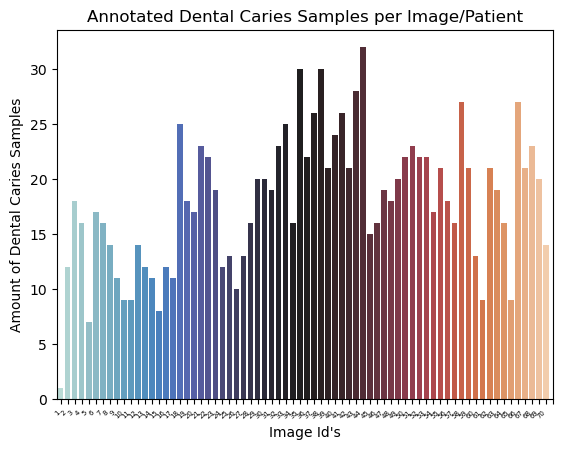

In [7]:
plt.title("Annotated Dental Caries Samples per Image/Patient")
sns.barplot(x=annot_df["image_id"].apply(str), y=annot_df["id_count"].apply(int), palette="icefire")
plt.xticks(range(71), rotation=45, ha='right', fontsize=5)
plt.xlabel('Image Id\'s')
plt.ylabel('Amount of Dental Caries Samples')
plt.show()

<Axes: title={'center': 'Frequency of Frequencies for id_count'}, xlabel='id_count', ylabel='count'>

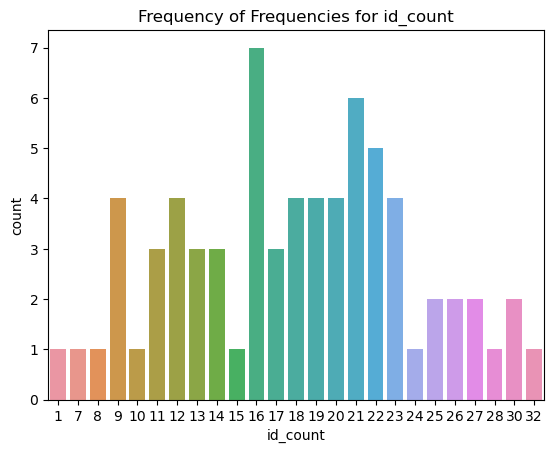

In [8]:
freqs = dict(zip(annot_df["image_id"], annot_df["id_count"]))
freqs_df = pd.DataFrame(list(freqs.items()), columns=["image_id", "id_count"])
plt.title("Frequency of Frequencies for id_count")
sns.countplot(freqs_df, x="id_count")

# there are 7 images that has 16 annotations

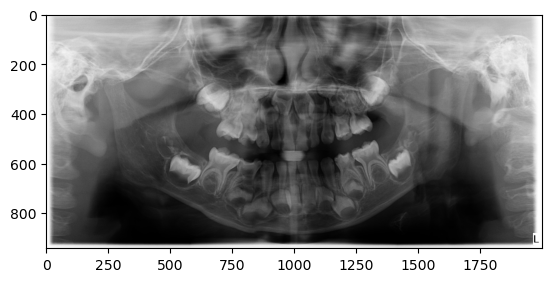

In [9]:
# example image
p5 = plt.imread("/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Childrens dental caries segmentation dataset/Train/images/cate1_005.png")
plt.imshow(p5)

## Setup Pycocotools

In [10]:
class SetupPipeline:
    @staticmethod
    def __pycocotools() -> None:
        if not os.path.exists("/kaggle/working/packages"):
            shutil.copytree("/kaggle/input/pycocotools/", "/kaggle/working/packages")
            os.chdir("/kaggle/working/packages/pycocotools-2.0.6/")
            os.system("python setup.py install")
            os.system("pip install . --no-index --find-links /kaggle/working/packages/")
            os.chdir("/kaggle/working")
            
    @staticmethod
    def __seed_everything(seed: int) -> None:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        
    def __call__(self, seed: int = 42, pycoco: bool = True) -> None:
        if seed: self.__seed_everything(seed)
        if pycoco: self.__pycocotools()
            
setup = SetupPipeline()
SEED: int = 42
setup(seed=SEED, pycoco=True)

running install


/opt/conda/lib/python3.10/site-packages/setuptools/command/install.py:34: SetuptoolsDeprecationWarning: setup.py install is deprecated. Use build and pip and other standards-based tools.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/setuptools/command/easy_install.py:156: EasyInstallDeprecationWarning: easy_install command is deprecated. Use build and pip and other standards-based tools.
  warnings.warn(


running bdist_egg
running egg_info
writing pycocotools.egg-info/PKG-INFO
writing dependency_links to pycocotools.egg-info/dependency_links.txt
writing requirements to pycocotools.egg-info/requires.txt
writing top-level names to pycocotools.egg-info/top_level.txt
reading manifest file 'pycocotools.egg-info/SOURCES.txt'
reading manifest template 'MANIFEST.in'
writing manifest file 'pycocotools.egg-info/SOURCES.txt'
installing library code to build/bdist.linux-x86_64/egg
running install_lib
running build_py
creating build
creating build/lib.linux-x86_64-3.10
creating build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/coco.py -> build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/__init__.py -> build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/cocoeval.py -> build/lib.linux-x86_64-3.10/pycocotools
copying pycocotools/mask.py -> build/lib.linux-x86_64-3.10/pycocotools
running build_ext
cythoning pycocotools/_mask.pyx to pycocotools/_mask.c


/opt/conda/lib/python3.10/site-packages/Cython/Compiler/Main.py:369: FutureWarning: Cython directive 'language_level' not set, using 2 for now (Py2). This will change in a later release! File: /kaggle/working/packages/pycocotools-2.0.6/pycocotools/_mask.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)


building 'pycocotools._mask' extension
creating build/temp.linux-x86_64-3.10
creating build/temp.linux-x86_64-3.10/common
creating build/temp.linux-x86_64-3.10/pycocotools
gcc -pthread -B /opt/conda/compiler_compat -Wno-unused-result -Wsign-compare -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/conda/include -fPIC -O2 -isystem /opt/conda/include -fPIC -I/opt/conda/lib/python3.10/site-packages/numpy/core/include -I./common -I/opt/conda/include/python3.10 -c ./common/maskApi.c -o build/temp.linux-x86_64-3.10/./common/maskApi.o -Wno-cpp -Wno-unused-function -std=c99


...

gcc -pthread -B /opt/conda/compiler_compat -Wno-unused-result -Wsign-compare -DNDEBUG -fwrapv -O2 -Wall -fPIC -O2 -isystem /opt/conda/include -fPIC -O2 -isystem /opt/conda/include -fPIC -I/opt/conda/lib/python3.10/site-packages/numpy/core/include -I./common -I/opt/conda/include/python3.10 -c pycocotools/_mask.c -o build/temp.linux-x86_64-3.10/pycocotools/_mask.o -Wno-cpp -Wno-unused-function -std=c99


pycocotools/_mask.c: In function ‘__pyx_pf_11pycocotools_5_mask_12iou’:
pycocotools/_mask.c:6140:31: warning: comparison of integer expressions of different signedness: ‘Py_ssize_t’ {aka ‘long int’} and ‘siz’ {aka ‘long unsigned int’} [-Wsign-compare]
 6140 |     if (unlikely(!((__pyx_t_8 == __pyx_v_n) != 0))) {
      |                               ^~
pycocotools/_mask.c:944:43: note: in definition of macro ‘unlikely’
  944 |   #define unlikely(x) __builtin_expect(!!(x), 0)
      |                                           ^


gcc -pthread -B /opt/conda/compiler_compat -shared -Wl,--allow-shlib-undefined -Wl,-rpath,/opt/conda/lib -Wl,-rpath-link,/opt/conda/lib -L/opt/conda/lib -Wl,--allow-shlib-undefined -Wl,-rpath,/opt/conda/lib -Wl,-rpath-link,/opt/conda/lib -L/opt/conda/lib build/temp.linux-x86_64-3.10/./common/maskApi.o build/temp.linux-x86_64-3.10/pycocotools/_mask.o -o build/lib.linux-x86_64-3.10/pycocotools/_mask.cpython-310-x86_64-linux-gnu.so
creating build/bdist.linux-x86_64
creating build/bdist.linux-x86_64/egg
creating build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/coco.py -> build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/__init__.py -> build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/cocoeval.py -> build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/pycocotools/mask.py -> build/bdist.linux-x86_64/egg/pycocotools
copying build/lib.linux-x86_64-3.10/p

zip_safe flag not set; analyzing archive contents...
pycocotools.__pycache__._mask.cpython-310: module references __file__
error: [Errno 2] No such file or directory: '/opt/conda/lib/python3.10/site-packages/numpy-1.24.3.dist-info/METADATA'


Looking in links: /kaggle/working/packages/
Processing /kaggle/working/packages/pycocotools-2.0.6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for pycocotools: filename=pycocotools-2.0.6-cp310-cp310-linux_x86_64.whl size=102202 sha256=d11fe0513ca006f7b0c92216aafe6ea1e779a019c5ab21c1a596c7ad77eb5903
  Stored in directory: /root/.cache/pip/wheels/b7/83/32/99474500256e64154dfc568319411b6ff49e96e50f30d9474f
Successfully built pycocotools
  Attempting uninstall: pycocotools
    Found existing installation: pycocotools 2.0.6
    Uninstalling pycocotools-2.0.6:
      Successfully uninstalled pycocotools-2.0.6


## Visualize Samples

In [11]:
from pycocotools.coco import COCO

coco_annotation = COCO(annotation_file=ANNOTATIONS_PATH)

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!


In [12]:
def show_and_save_annotated_example(idx: int, PATH: str):
    # Category IDs
    cat_ids = coco_annotation.getCatIds()
    print(f"Number of Unique Categories: {len(cat_ids)}")
    print("Category IDs:")
    print(cat_ids)

    # All categories
    cats = coco_annotation.loadCats(cat_ids)
    cat_names = [cat["name"] for cat in cats]
    print("Categories Names:")
    print(cat_names)

    # Category ID -> Category Name
    query_id = cat_ids[0]
    query_annotation = coco_annotation.loadCats([query_id])[0]
    query_name = query_annotation["name"]
    query_supercategory = query_annotation["supercategory"]
    print("Category ID -> Category Name:")
    print(
        f"Category ID: {query_id}, Category Name: {query_name}, Supercategory: {query_supercategory}"
    )

    # Category Name -> Category ID.
    query_name = cat_names[0]
    query_id = coco_annotation.getCatIds(catNms=[query_name])[0]
    print("Category Name -> ID:")
    print(f"Category Name: {query_name}, Category ID: {query_id}")

    # Get the ID of all the images containing the object of the category.
    img_ids = coco_annotation.getImgIds(catIds=[query_id])
    print(f"Number of Images Containing {query_name}: {len(img_ids)}")

    # Pick one image.
    img_id = img_ids[idx]
    img_info = coco_annotation.loadImgs([img_id])[0]
    img_file_name = img_info["file_name"]
    img_url = img_info["coco_url"]
    print(
        f"Image ID: {img_id}, File Name: {img_file_name}, Image URL: {img_url}"
    )

    # Get all the annotations for the specified image.
    ann_ids = coco_annotation.getAnnIds(imgIds=[img_id], iscrowd=None)
    anns = coco_annotation.loadAnns(ann_ids)
    print(f"Annotations for Image ID {img_id}:")
    print(anns)

    # Use URL to load image.
    im = Image.open(os.path.join(PATH, f"images/{img_file_name}"))

    # Save image and its labeled version.
    plt.axis("off")
    plt.imshow(np.asarray(im))
    plt.savefig(f"{img_id}.jpg", bbox_inches="tight", pad_inches=0)
    # Plot segmentation and bounding box.
    coco_annotation.showAnns(anns, draw_bbox=True)
    plt.savefig(f"{img_id}_annotated.jpg", bbox_inches="tight", pad_inches=0)

Number of Unique Categories: 1
Category IDs:
[1]
Categories Names:
['龋齿分割']
Category ID -> Category Name:
Category ID: 1, Category Name: 龋齿分割, Supercategory: 
Category Name -> ID:
Category Name: 龋齿分割, Category ID: 1
Number of Images Containing 龋齿分割: 70
Image ID: 6, File Name: cate1_005.png, Image URL: 
Annotations for Image ID 6:
[{'id': 55, 'iscrowd': 0, 'image_id': 6, 'category_id': 1, 'segmentation': [[679.0, 277.0, 670.0, 278.0, 648.0, 288.0, 643.0, 291.0, 640.0, 294.0, 626.0, 304.0, 624.0, 307.0, 621.0, 310.0, 614.0, 321.0, 608.0, 335.0, 607.0, 357.0, 608.0, 360.0, 611.0, 363.0, 618.0, 366.0, 634.0, 366.0, 644.0, 382.0, 660.0, 394.0, 677.0, 392.0, 689.0, 392.0, 701.0, 389.0, 714.0, 379.0, 736.0, 345.0, 739.0, 333.0, 739.0, 322.0, 738.0, 314.0, 735.0, 307.0, 704.0, 288.0, 685.0, 279.0]], 'area': 11022.5, 'bbox': [607.0, 277.0, 132.0, 117.0]}, {'id': 56, 'iscrowd': 0, 'image_id': 6, 'category_id': 1, 'segmentation': [[915.0, 444.0, 917.0, 480.0, 911.0, 502.0, 907.0, 512.0, 907.0, 53

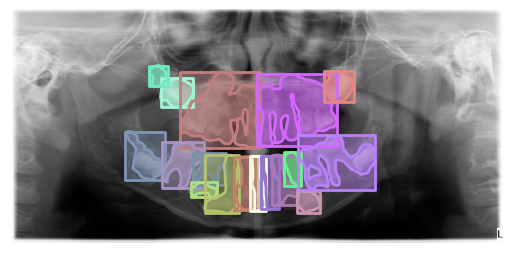

In [13]:
show_and_save_annotated_example(5, TRAIN_PATH)

Number of Unique Categories: 1
Category IDs:
[1]
Categories Names:
['龋齿分割']
Category ID -> Category Name:
Category ID: 1, Category Name: 龋齿分割, Supercategory: 
Category Name -> ID:
Category Name: 龋齿分割, Category ID: 1
Number of Images Containing 龋齿分割: 70
Image ID: 43, File Name: cate4_000.png, Image URL: 
Annotations for Image ID 43:
[{'id': 710, 'iscrowd': 0, 'image_id': 43, 'category_id': 1, 'segmentation': [[455.0, 490.0, 446.0, 497.0, 444.0, 501.0, 447.0, 509.0, 451.0, 510.0, 460.0, 519.0, 463.0, 524.0, 464.0, 532.0, 469.0, 543.0, 476.0, 553.0, 481.0, 562.0, 482.0, 567.0, 481.0, 571.0, 483.0, 575.0, 486.0, 578.0, 489.0, 585.0, 493.0, 587.0, 508.0, 587.0, 522.0, 576.0, 523.0, 566.0, 527.0, 557.0, 529.0, 547.0, 528.0, 532.0, 518.0, 521.0, 514.0, 520.0, 509.0, 517.0, 503.0, 505.0, 493.0, 495.0, 485.0, 484.0, 475.0, 483.0]], 'area': 4948.0, 'bbox': [444.0, 483.0, 85.0, 104.0]}, {'id': 711, 'iscrowd': 0, 'image_id': 43, 'category_id': 1, 'segmentation': [[553.0, 196.0, 548.0, 198.0, 547.0

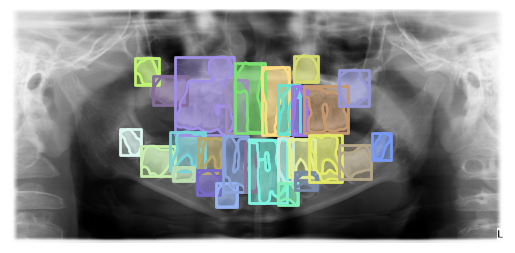

In [14]:
show_and_save_annotated_example(42, TRAIN_PATH)

Number of Unique Categories: 1
Category IDs:
[1]
Categories Names:
['龋齿分割']
Category ID -> Category Name:
Category ID: 1, Category Name: 龋齿分割, Supercategory: 
Category Name -> ID:
Category Name: 龋齿分割, Category ID: 1
Number of Images Containing 龋齿分割: 70
Image ID: 68, File Name: cate5_011.png, Image URL: 
Annotations for Image ID 68:
[{'id': 1202, 'iscrowd': 0, 'image_id': 68, 'category_id': 1, 'segmentation': [[510.0, 545.0, 508.0, 551.0, 510.0, 555.0, 522.0, 570.0, 528.0, 587.0, 544.0, 608.0, 555.0, 620.0, 559.0, 626.0, 569.0, 625.0, 577.0, 615.0, 586.0, 598.0, 587.0, 591.0, 586.0, 590.0, 586.0, 587.0, 584.0, 581.0, 561.0, 563.0, 553.0, 555.0, 544.0, 551.0, 540.0, 551.0, 528.0, 546.0, 522.0, 540.0]], 'area': 3387.5, 'bbox': [508.0, 540.0, 79.0, 86.0]}, {'id': 1203, 'iscrowd': 0, 'image_id': 68, 'category_id': 1, 'segmentation': [[547.0, 326.0, 550.0, 336.0, 559.0, 335.0, 565.0, 337.0, 567.0, 340.0, 569.0, 345.0, 577.0, 352.0, 582.0, 360.0, 584.0, 361.0, 591.0, 360.0, 596.0, 357.0, 604.

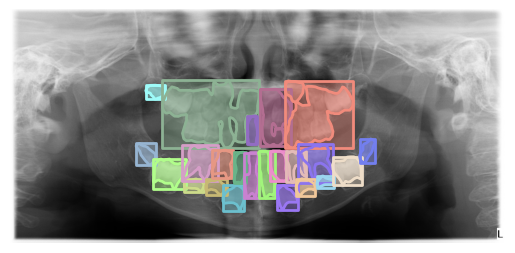

In [15]:
show_and_save_annotated_example(67, TRAIN_PATH)

## Just Bboxes

In [16]:
def show_bbox_image(idx: int):
    cat_ids = coco_annotation.getCatIds()
    query_id = cat_ids[0]
    cats = coco_annotation.loadCats(cat_ids)
    cat_names = [cat["name"] for cat in cats]
    query_name = cat_names[0]
    query_id = coco_annotation.getCatIds(catNms=[query_name])[0]
    img_ids = coco_annotation.getImgIds(catIds=[query_id])
    img_id = img_ids[idx]
    img_info = coco_annotation.loadImgs([img_id])[0]
    img_file_name = img_info["file_name"]
    img_url = img_info["coco_url"]
    print(
        f"Image ID: {img_id}, File Name: {img_file_name}, Image URL: {img_url}"
    )

    # Get all the annotations for the specified image.
    ann_ids = coco_annotation.getAnnIds(imgIds=[img_id], iscrowd=None)
    anns = coco_annotation.loadAnns(ann_ids)
    image = Image.open(os.path.join(TRAIN_PATH, f"images/{img_file_name}"))

    fig, ax = plt.subplots()

    for ann in anns:
        box = ann['bbox']
        bb = patches.Rectangle((box[0],box[1]), box[2],box[3], linewidth=1, edgecolor="blue", facecolor="none")
        ax.add_patch(bb)

    ax.imshow(image)
    plt.show()

Image ID: 6, File Name: cate1_005.png, Image URL: 


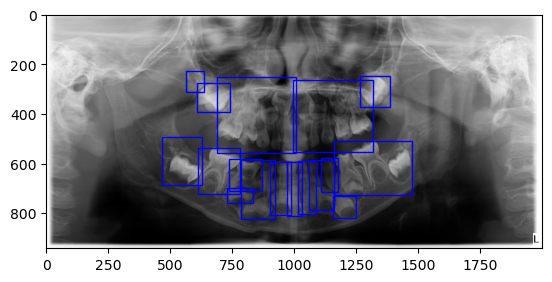

In [17]:
show_bbox_image(5)

Image ID: 43, File Name: cate4_000.png, Image URL: 


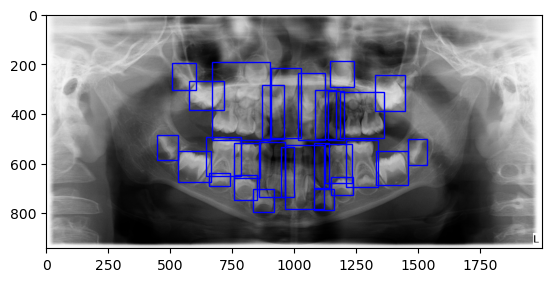

In [18]:
show_bbox_image(42)

Image ID: 70, File Name: cate5_013.png, Image URL: 


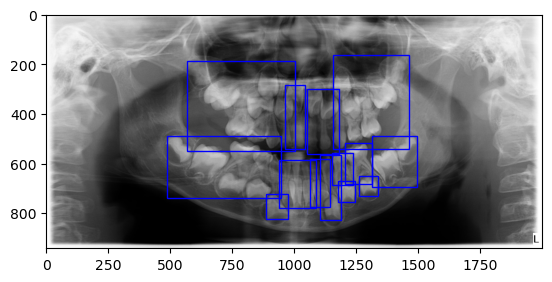

In [19]:
show_bbox_image(69)

# Pediatric Dental Disease Detection Dataset

In [20]:
BASE_PATH = "/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Pediatric dental disease detection dataset"
TRAIN_PATH = os.path.join(BASE_PATH, "Train")
TEST_PATH = os.path.join(BASE_PATH, "Test")

print(os.listdir(BASE_PATH))

['Test', 'Train']


In [21]:
# test
with open("/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Pediatric dental disease detection dataset/Train/label/cate3_000.json", "r") as f:
    a = json.load(f)
    
print(a.keys(), end="\n\n")
print(a["shapes"])
# there are bboxes and labels

dict_keys(['version', 'flags', 'shapes', 'imagePath', 'imageData', 'imageHeight', 'imageWidth'])

[{'label': '牙齿发育异常', 'points': [[1166.289156626506, 434.433734939759], [1216.8915662650602, 591.0602409638552]], 'group_id': None, 'shape_type': 'rectangle', 'flags': {}}, {'label': '牙齿发育异常', 'points': [[1174.722891566265, 582.6265060240962], [1240.987951807229, 744.0722891566263]], 'group_id': None, 'shape_type': 'rectangle', 'flags': {}}]


<div class="alert alert-block alert-info" style="font-size:20px; background-color: #d1a6ff; font-family:verdana; color: #533078; border: 3px #533078 solid">
    <b>Chinese Labels ⚕️</b>
    <br>The labels are in Chinese. Here are equivalents:
    <ul style="list-style-type: none; padding-left: 0;">
        <li>* 其他 = other</li>
        <li>* 牙髓炎 = pulpitis</li>
        <li>* 龋病 = caries</li>
        <li>* 深窝沟 = deep pit</li>
        <li>* 根尖周炎 = apical periodontitis</li>
        <li>* 牙齿发育异常 = abnormal tooth development</li>
    </ul>
</div>

In [22]:
chinese_to_english = {
    "其他": "other",
    "牙髓炎": "pulpitis",
    "龋病": "caries",
    "深窝沟": "deep pit",
    "根尖周炎": "apical periodontitis",
    "牙齿发育异常": "abnormal tooth development",
}

In [23]:
colors = ["red", "lime", "orange", "blue", "magenta", "yellow", "pink", "azure"]

In [24]:
def show_bbox_image(path: str):
    with open(path, "r") as jsonfile:
        annot = json.load(jsonfile)
    
    shapes = annot["shapes"]
    filename = annot['imagePath']
    filename = filename[3:] if filename.startswith('..') else filename
    image_path = os.path.join(TRAIN_PATH, f"images/{filename}")
    
    fig, ax = plt.subplots()
    
    labels = []
    
    for i, sample in enumerate(shapes):
        bbox_points = sample["points"]
        ch_label = sample["label"]
        en_label = chinese_to_english[ch_label]
        labels.append(en_label)
        image = Image.open(image_path)

        # Draw boxes and add label to each box
        c = bbox_points[0]
        w, h = bbox_points[1]
        bb = patches.Rectangle((c[0],c[1]), w-c[0], h-c[1], linewidth=1, edgecolor=colors[i], facecolor="none")
        ax.add_patch(bb)
    
    ax.legend(labels=labels, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.title(f"Patient: {filename}")
    ax.imshow(image)
    plt.show()

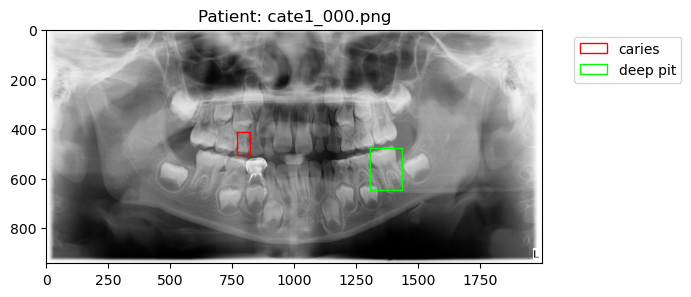

In [25]:
show_bbox_image("/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Pediatric dental disease detection dataset/Train/label/cate1_000.json")

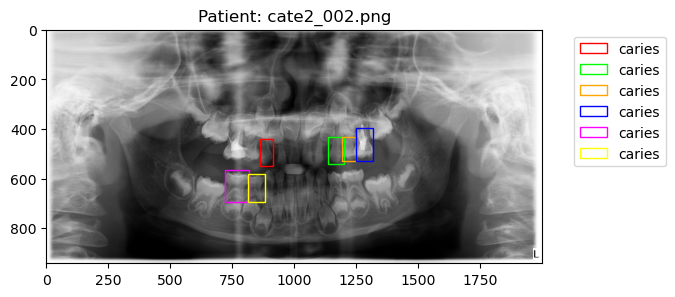

In [26]:
show_bbox_image("/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Pediatric dental disease detection dataset/Train/label/cate2_002.json")

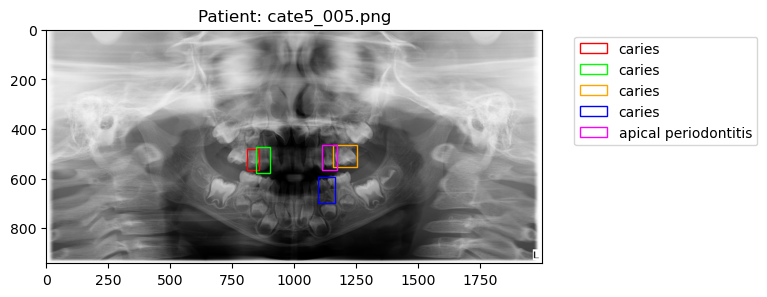

In [27]:
show_bbox_image("/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Pediatric dental disease detection dataset/Train/label/cate5_005.json")

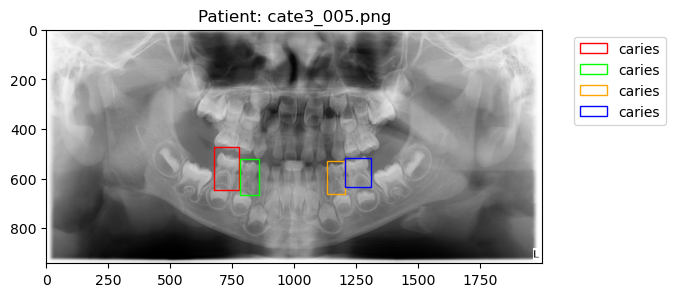

In [28]:
show_bbox_image("/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Pediatric dental disease detection dataset/Train/label/cate3_005.json")

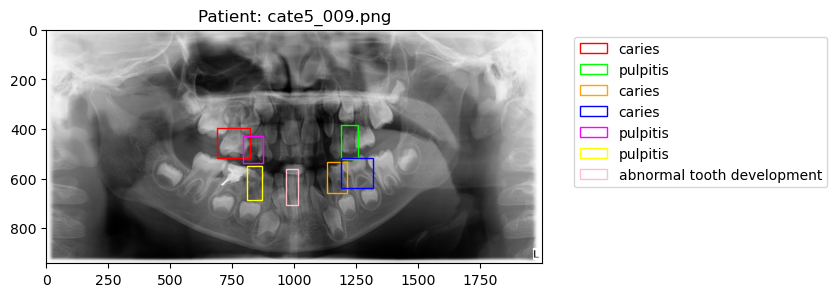

In [29]:
show_bbox_image("/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Pediatric dental disease detection dataset/Train/label/cate5_009.json")

# Adult Tooth Segmentation Dataset

In [30]:
BASE_PATH = "/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Adult tooth segmentation dataset"

print(os.listdir(BASE_PATH))

['Panoramic radiography database', 'Dataset and code', 'Archive']


In [31]:
PANORAMIC_PATH = os.path.join(BASE_PATH, 'Panoramic radiography database')
DC_PATH = os.path.join(BASE_PATH, 'Dataset and code')
ARCH_PATH = os.path.join(BASE_PATH, 'Archive')

print('Panoramic radiography database:') # semantic segmentation
print(os.listdir(PANORAMIC_PATH))
print('\nDataset and code:') # instance segmentation
print(os.listdir(DC_PATH))
print('\nArchive:') # semantic segmentation
print(os.listdir(ARCH_PATH))

Panoramic radiography database:
['images', 'mask']

Dataset and code:
['test', 'train']

Archive:
['images', 'mask']


In [32]:
coco_annotation = COCO(annotation_file="/kaggle/input/childrens-dental-panoramic-radiographs-dataset/Dental_dataset/Adult tooth segmentation dataset/Dataset and code/train/annotations/train.json")

loading annotations into memory...
Done (t=1.82s)
creating index...
index created!


Number of Unique Categories: 1
Category IDs:
[1]
Categories Names:
['tooth']
Category ID -> Category Name:
Category ID: 1, Category Name: tooth, Supercategory: teeth
Category Name -> ID:
Category Name: tooth, Category ID: 1
Number of Images Containing tooth: 1224
Image ID: 5, File Name: cate8-00350.jpg, Image URL: 
Annotations for Image ID 5:
[{'bbox': [283.0, 134.0, 1423.0, 722.0], 'category_id': 1, 'area': 512485, 'image_id': 5, 'id': 5, 'height': 1127, 'segmentation': {'counts': [319496, 3, 1119, 11, 1111, 19, 1103, 27, 1096, 34, 1088, 42, 1080, 50, 1075, 55, 1071, 58, 1068, 61, 1066, 60, 1066, 61, 1065, 61, 1066, 61, 1065, 61, 1066, 61, 1065, 62, 1064, 62, 1065, 62, 30, 1, 1033, 62, 29, 4, 1031, 63, 27, 7, 1030, 62, 26, 10, 1028, 63, 23, 14, 1027, 62, 22, 17, 1025, 63, 20, 20, 1023, 64, 18, 23, 1022, 63, 17, 26, 1020, 64, 16, 28, 1018, 64, 16, 30, 1017, 64, 16, 31, 1015, 64, 16, 33, 1014, 64, 16, 34, 1012, 64, 17, 35, 1010, 65, 16, 36, 1010, 65, 16, 37, 1008, 65, 16, 39, 1006, 66, 

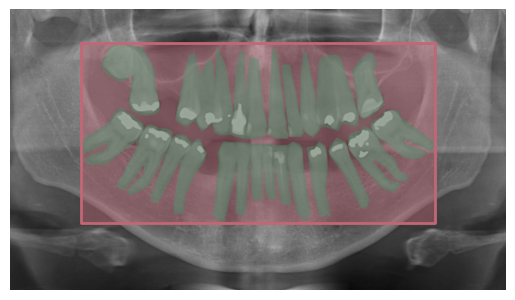

In [33]:
show_and_save_annotated_example(5, f"{DC_PATH}/train")

Number of Unique Categories: 1
Category IDs:
[1]
Categories Names:
['tooth']
Category ID -> Category Name:
Category ID: 1, Category Name: tooth, Supercategory: teeth
Category Name -> ID:
Category Name: tooth, Category ID: 1
Number of Images Containing tooth: 1224
Image ID: 25, File Name: cate6-00101.jpg, Image URL: 
Annotations for Image ID 25:
[{'bbox': [234.0, 174.0, 1561.0, 789.0], 'category_id': 1, 'area': 566115, 'image_id': 25, 'id': 25, 'height': 1127, 'segmentation': {'counts': [264353, 1, 1122, 7, 1116, 13, 1110, 19, 1104, 24, 1098, 31, 1092, 37, 1089, 40, 1086, 43, 1083, 46, 1079, 50, 1076, 52, 1074, 55, 1070, 59, 1067, 62, 1064, 65, 1061, 67, 1058, 70, 1056, 72, 1054, 75, 1051, 77, 1048, 80, 1046, 82, 1044, 85, 1040, 88, 1038, 90, 1036, 92, 1034, 95, 1030, 98, 1028, 100, 1026, 102, 1024, 105, 1020, 108, 1018, 110, 1016, 112, 1013, 115, 1011, 117, 1009, 118, 1008, 120, 1005, 122, 1004, 123, 1003, 125, 1000, 127, 999, 128, 998, 130, 996, 131, 994, 134, 992, 135, 991, 136, 989,

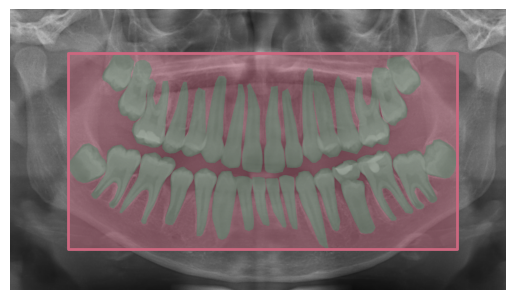

In [34]:
show_and_save_annotated_example(25, f"{DC_PATH}/train")

Number of Unique Categories: 1
Category IDs:
[1]
Categories Names:
['tooth']
Category ID -> Category Name:
Category ID: 1, Category Name: tooth, Supercategory: teeth
Category Name -> ID:
Category Name: tooth, Category ID: 1
Number of Images Containing tooth: 1224
Image ID: 42, File Name: cate4-00056.jpg, Image URL: 
Annotations for Image ID 42:
[{'bbox': [228.0, 268.0, 1532.0, 580.0], 'category_id': 1, 'area': 500246, 'image_id': 42, 'id': 42, 'height': 1127, 'segmentation': {'counts': [257672, 9, 1115, 14, 1110, 19, 1105, 24, 1101, 27, 1098, 30, 1095, 32, 1093, 35, 1090, 38, 1088, 39, 1086, 41, 1084, 43, 1082, 45, 1080, 47, 1078, 50, 1075, 52, 1074, 53, 1072, 55, 1070, 57, 1068, 59, 1066, 61, 1065, 62, 1063, 64, 1061, 65, 1060, 67, 1059, 68, 1057, 70, 1055, 71, 1055, 71, 1054, 72, 1053, 74, 1052, 74, 1051, 75, 4, 5, 1041, 76, 1, 10, 1038, 76, 1, 13, 1035, 76, 2, 15, 1032, 77, 2, 16, 1030, 78, 1, 19, 1027, 79, 1, 20, 1025, 80, 1, 21, 1023, 81, 1, 23, 1020, 107, 1018, 82, 1, 26, 1016, 8

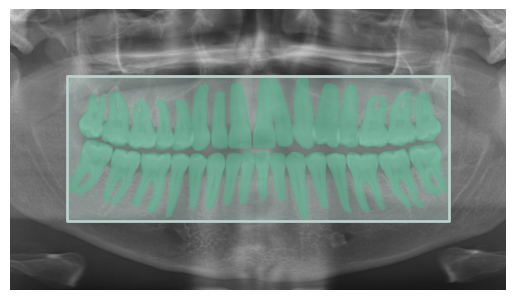

In [35]:
show_and_save_annotated_example(42, f"{DC_PATH}/train")